# Setup

In [1]:
# รันทุกครั้ง
import os
import gc
import time
import warnings
import itertools
from collections import defaultdict

import numpy as np
import pandas as pd
import faiss
import hnswlib
# import psutil
import numpy.linalg as LA

from sklearn.cluster import MiniBatchKMeans
from sklearn.datasets import make_blobs, make_classification

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

BASE = os.path.expanduser("~/Downloads/ANN_Hybrid_GenerateData_test")
print(f"Project base path set to: {BASE}")

folders = [
    "results",
    "figs",
]
for folder in folders:
    os.makedirs(os.path.join(BASE, folder), exist_ok=True)

FIG_DIR = os.path.join(BASE, "figs")
RESULT_PATH = os.path.join(BASE, "results", "smooth_trend_results.csv")

# ค่าคงที่สำหรับการทดลอง
KS = (5, 10, 20, 50, 100)
RUNS = 100
DATASET = "SYNTHETIC_TRENDS"
DEFAULT_QUERY = 300

print("KS =", KS)
print("RUNS =", RUNS)
print("DATASET =", DATASET)


Project base path set to: /Users/bew/Downloads/ANN_Hybrid_GenerateData_test
KS = (5, 10, 20, 50, 100)
RUNS = 100
DATASET = SYNTHETIC_TRENDS


## Dataset Generator

In [2]:

def generate_dataset(
    n_base,
    n_dimensions,
    n_clusters,
    n_learn=None,
    n_query=1000,
    generator="blobs",
    cluster_std=1.5,
    class_sep=1.0,
    random_state=42,
):
    """
    สร้าง Synthetic Dataset สำหรับงาน ANN
    - generator='blobs'          -> กลุ่ม Gaussian ชัดเจน
    - generator='classification' -> ข้อมูลเชิง class ที่มีความซับซ้อนขึ้น
    """
    if n_learn is None:
        n_learn = min(50000, max(10000, int(n_base * 0.1)))

    total_samples = n_base + n_learn + n_query

    if generator == "blobs":
        X, y = make_blobs(
            n_samples=total_samples,
            n_features=n_dimensions,
            centers=n_clusters,
            cluster_std=cluster_std,
            random_state=random_state,
        )
    elif generator == "classification":
        n_informative = max(2, min(n_dimensions, n_dimensions // 2))
        n_redundant = max(0, min(n_dimensions - n_informative, n_dimensions // 4))
        X, y = make_classification(
            n_samples=total_samples,
            n_features=n_dimensions,
            n_informative=n_informative,
            n_redundant=n_redundant,
            n_repeated=0,
            n_classes=n_clusters,
            n_clusters_per_class=1,
            class_sep=class_sep,
            random_state=random_state,
        )
    else:
        raise ValueError("generator must be 'blobs' or 'classification'")

    # L2-normalize
    X = X.astype("float32")
    norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-12
    X = (X / norms).astype("float32")

    X_learn = X[:n_learn].copy()
    X_query = X[n_learn:n_learn+n_query].copy()
    X_base = X[n_learn+n_query:].copy()

    y_learn = y[:n_learn].copy()
    y_query = y[n_learn:n_learn+n_query].copy()
    y_base = y[n_learn+n_query:].copy()

    # Ground Truth แบบ exact search
    gt_index = faiss.IndexFlatL2(n_dimensions)
    gt_index.add(X_base)
    _, GT = gt_index.search(X_query, max(KS))

    meta = {
        "n_base": n_base,
        "n_dimensions": n_dimensions,
        "n_clusters": n_clusters,
        "n_learn": n_learn,
        "n_query": n_query,
        "generator": generator,
    }
    return X_base, X_query, X_learn, GT.astype("int32"), y_base, y_query, y_learn, meta


In [3]:
Xb_demo, Q_demo, X_learn_demo, GT_demo, yb_demo, yq_demo, yl_demo, meta_demo = generate_dataset(
    n_base=10000,
    n_dimensions=128,
    n_clusters=32,
    n_query=300,
    generator="blobs",
)
print("Xb_demo      :", Xb_demo.shape, Xb_demo.dtype)
print("Q_demo       :", Q_demo.shape, Q_demo.dtype)
print("GT_demo      :", GT_demo.shape, GT_demo.dtype)
print("X_learn_demo :", X_learn_demo.shape, X_learn_demo.dtype)

print("\nXb_demo:")
print(Xb_demo[:3, :10])

print("\nQ_demo:")
print(Q_demo[:3, :10])

print("\nGT_demo:")
print(GT_demo[:3, :10])

print("\nX_learn_demo:")
print(X_learn_demo[:3, :10])

print("\nmeta_demo:")
print(meta_demo)

Xb_demo      : (10000, 128) float32
Q_demo       : (300, 128) float32
GT_demo      : (300, 100) int32
X_learn_demo : (10000, 128) float32

Xb_demo:
[[ 0.02444649 -0.14749958  0.01879483 -0.02667842  0.09394985 -0.14725989
   0.00403925 -0.0128643   0.01802243 -0.0959591 ]
 [ 0.00588223  0.05345782  0.01003676 -0.0249441  -0.17349182 -0.01344879
   0.13702552  0.02215082  0.05012375 -0.0433693 ]
 [-0.1271544  -0.05095594 -0.06474468 -0.04548869 -0.1702834   0.1454997
   0.03825469  0.02826487  0.11645585 -0.0249473 ]]

Q_demo:
[[ 0.0165308   0.07092854  0.05301707  0.07515562 -0.03857816 -0.10473015
   0.07642513  0.06095145 -0.09264395  0.03719317]
 [ 0.04878812  0.08226169  0.07898701  0.04958586 -0.10436092  0.11953516
   0.12856606 -0.10241514  0.07441507 -0.10653482]
 [ 0.15198198 -0.04675684  0.13313948 -0.04895659 -0.04588121 -0.04237317
   0.03636471 -0.13858268  0.0070724   0.01357822]]

GT_demo:
[[6746 6544 5759 1821 2480 8208 4207 3673  467 1381]
 [7911 7305 8366 5812 6940 88

## Evaluation + Memory Utilities

In [4]:
# process = psutil.Process(os.getpid())

# def get_current_rss_mb():
#     gc.collect()
#     return process.memory_info().rss / (1024 ** 2)
#
# def get_peak_rss_mb():
#     try:
#         import resource
#         peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
#         import sys
#         if sys.platform == "darwin":
#             return peak / (1024 ** 2)
#         return peak / 1024.0
#     except Exception:
#         return get_current_rss_mb()

def precision_at_k(gt, pred, k):
    return float(np.mean([
        len(set(g[:k]) & set(p[:k])) / max(1, len(p[:k]))
        for g, p in zip(gt, pred)
    ]))

def recall_at_k(gt, pred, k):
    return float(np.mean([
        len(set(g[:k]) & set(p[:k])) / max(1, len(g[:k]))
        for g, p in zip(gt, pred)
    ]))

def f1_from_pr(p, r):
    return 0.0 if (p + r) == 0 else (2 * p * r) / (p + r)

def measure_build(build_func, *args, **kwargs):
    gc.collect()
    # rss_before = get_current_rss_mb()
    t0 = time.perf_counter()
    obj = build_func(*args, **kwargs)
    build_s = time.perf_counter() - t0
    # rss_after = get_current_rss_mb()
    return obj, {
        "build_time_s": float(build_s)
    }

def _unwrap_pred(result):
    if isinstance(result, tuple):
        return result[0]
    return result

def measure_latency_and_recall(search_func, index_obj, Q, GT, ks=KS, runs=RUNS):
    warm_up = min(len(Q), 100)
    _ = _unwrap_pred(search_func(index_obj, Q[:warm_up], min(10, max(ks))))

    perq_times = []
    P = {k: [] for k in ks}
    R = {k: [] for k in ks}

    # peak_before = get_peak_rss_mb()

    for _ in range(runs):
        t0 = time.perf_counter()
        I = _unwrap_pred(search_func(index_obj, Q, max(ks)))
        dt = time.perf_counter() - t0
        perq_times.append((dt / len(Q)) * 1000.0)

        for k in ks:
            p = precision_at_k(GT, I, k)
            r = recall_at_k(GT, I, k)
            P[k].append(p)
            R[k].append(r)

    # peak_after = get_peak_rss_mb()

    res = {
        "latency_mean_ms": float(np.mean(perq_times)),
        "latency_std_ms": float(np.std(perq_times)),
        # "peak_retrieval_ram_mb": float(max(0.0, peak_after - peak_before)),
    }

    for k in ks:
        p = float(np.mean(P[k]))
        r = float(np.mean(R[k]))
        res[f"precision@{k}"] = p
        res[f"recall@{k}"] = r
        res[f"f1@{k}"] = f1_from_pr(p, r)

    return res


## Algorithms

In [5]:
# 1. PQ Functions
def build_pq(X_learn, X_base, d, nlist, m, nbits=8):
    coarse = faiss.IndexFlatL2(d)
    pq_idx = faiss.IndexIVFPQ(coarse, d, nlist, m, nbits)
    pq_idx.train(X_learn)
    pq_idx.add(X_base)
    return pq_idx

def search_pq(index, Q, k):
    _, I = index.search(Q, k)
    return I

# 2. HNSW Functions
def build_hnsw(X_base, d, M=16, efC=200):
    hnsw_idx = hnswlib.Index(space="l2", dim=d)
    hnsw_idx.init_index(max_elements=X_base.shape[0], ef_construction=efC, M=M)
    hnsw_idx.add_items(X_base, np.arange(X_base.shape[0]))
    return hnsw_idx

def search_hnsw(index, Q, k):
    labels, _ = index.knn_query(Q, k=k)
    return labels

# 3. FaissHNSW (Flat) Functions
def build_faiss_hnsw(X_base, d, M=16, efC=200):
    index = faiss.IndexHNSWFlat(d, M)
    index.hnsw.efConstruction = efC
    # วิธี Flat ไม่ต้อง Train สามารถ Add ได้เลย
    index.add(X_base)
    return index

def search_faiss_hnsw(index, Q, k):
    _, I = index.search(Q, k)
    return I

# 4. HNSW-PQ (FAISS) Functions
def build_hnsw_pq(X_learn, X_base, d, M=16, m=8, efC=200):
    index = faiss.IndexHNSWPQ(d, m, M)
    index.hnsw.efConstruction = efC
    index.train(X_learn)
    index.add(X_base)
    return index

def search_hnswpq(index, Q, k):
    _, I = index.search(Q, k)
    return I

# 5. HANNIS Functions
def build_hannis(X_learn, X_base, d, n_clusters):
    dynamic_batch = min(4096, max(256, X_learn.shape[0] // 4))

    km = MiniBatchKMeans(
        n_clusters=n_clusters,
        batch_size=dynamic_batch,
        random_state=42,
        n_init="auto",
    )
    km.fit(X_learn)
    centroids = km.cluster_centers_.astype("float32")
    labels = km.predict(X_base).astype("int32")

    loaded_hannis_ram = {}
    for c in range(n_clusters):
        idxs = np.where(labels == c)[0]
        if idxs.size == 0: continue

        h = hnswlib.Index(space="l2", dim=d)
        h.init_index(max_elements=idxs.size, ef_construction=200, M=16)
        h.add_items(X_base[idxs], idxs)
        loaded_hannis_ram[c] = h

    return centroids, labels, loaded_hannis_ram

def search_hannis(index_pack, Q, k, topG=3, ef_base=120):
    centroids, _, loaded_hannis_ram = index_pack
    out = []

    # วนลูปคิวรี่
    for q in Q:
        # หาระยะห่างจากคิวรี่ไปคลัสเตอร์
        distances = {}

        for index, c in enumerate(centroids):
            dist = LA.norm(c - q)
            distances[index] = dist

        # เรียงคลัสเตอร์จาก centroid ที่ใกล้ที่สุดไปไกลที่สุด
        sorted_distances = dict(sorted(distances.items(), key=lambda item: item[1]))

        # ที่เก็บผลลัพธ์ใช้ List ว่าง
        final_data = []

        # วนลูปเข้าคลัสเตอร์ตามจำนวน topG
        for i in range(min(topG, len(sorted_distances))):
            # ดึง ID ของคลัสเตอร์ตามลำดับที่เรียงไว้
            c_idx = list(sorted_distances.keys())[i]

            if c_idx not in loaded_hannis_ram:
                continue

            h = loaded_hannis_ram[c_idx]
            cnt = h.get_current_count()
            if cnt <= 0:
                continue

            # ถ้าคลัสเตอร์มีข้อมูลไม่ถึง k ก็ขอได้แค่เท่าที่มี
            kc = min(k, cnt)
            h.set_ef(ef_base)

            # ค้นหาในกราฟย่อย
            success = False
            while kc > 0 and not success:
                try:
                    labs, dists = h.knn_query(np.expand_dims(q, axis=0), k=kc)
                    success = True
                except RuntimeError:
                    kc -= 1

            if not success: continue

            # เอาผลแต่ละตัวมายัดรวมใน final_data
            for label, dist in zip(labs[0], dists[0]):
                final_data.append((label, dist))

        # Sort รวดเดียวตอนจบ (อยู่นอกลูปคลัสเตอร์ แต่อยู่ในลูปคิวรี่)
        if len(final_data) > 0:
            # เอาผลจากทุกคลัสเตอร์มาเรียงใหม่โดยดูว่าใครใกล้ query ที่สุด
            sorted_final_data = sorted(final_data, key=lambda x: x[1])

            # ตัดหางเอาแค่ k ตัวแรก
            best_k = sorted_final_data[:k]

            # ดึงเฉพาะ label ออกมา
            final_labels = [item[0] for item in best_k if item[0] != -1]
            out.append(final_labels)
        else:
            out.append([])

    return np.array(out, dtype=object)

# 6. Hybrid Functions
def make_hybrid_pq_hannis_search(
    pq_index, id_to_cluster_map, loaded_hannis_ram, centroids,
    prefilter_k=2000, ef_base=120, topG=3, pq_batch_size=128
):
    C = centroids.astype(np.float32, copy=False)
    id_to_cluster_map = id_to_cluster_map.astype(np.int32, copy=False)

    def _search(Q, k=100):
        Q = Q.astype(np.float32, copy=False)
        nQ = Q.shape[0]

        top_dists = np.full((nQ, k), np.inf, dtype=np.float32)
        top_labels = np.full((nQ, k), -1, dtype=np.int32)
        cluster_to_queries = defaultdict(list)

        for start in range(0, nQ, pq_batch_size):
            end = min(start + pq_batch_size, nQ)
            q_batch = Q[start:end]

            _, cand_ids = pq_index.search(q_batch, prefilter_k)

            for local_qi in range(end - start):
                qi = start + local_qi
                ids = cand_ids[local_qi]
                ids = ids[ids >= 0]
                if ids.size == 0: continue

                cids = id_to_cluster_map[ids]
                uniq, cnt = np.unique(cids, return_counts=True)

                q_vec = Q[qi]
                diff = C[uniq] - q_vec
                cen_d = np.einsum("ij,ij->i", diff, diff).astype(np.float32, copy=False)

                order = np.lexsort((cen_d, -cnt))
                picked = uniq[order[:max(1, topG)]]

                for cid in picked:
                    cluster_to_queries[int(cid)].append(qi)
            del cand_ids

        temp_d = np.empty(2 * k, dtype=np.float32)
        temp_l = np.empty(2 * k, dtype=np.int32)

        for cid, q_indices in cluster_to_queries.items():
            h = loaded_hannis_ram.get(cid)
            if h is None: continue
            cnt = h.get_current_count()
            if cnt <= 0: continue

            kc = min(k, cnt)
            h.set_ef(ef_base)
            q_batch = Q[q_indices]

            try:
                labs, dists = h.knn_query(q_batch, k=kc)
            except RuntimeError:
                labs = np.full((len(q_indices), kc), -1, dtype=np.int32)
                dists = np.full((len(q_indices), kc), np.inf, dtype=np.float32)
                for _i, _q in enumerate(q_batch):
                    _kc = kc
                    while _kc > 0:
                        try:
                            _l, _d = h.knn_query(np.expand_dims(_q, axis=0), k=_kc)
                            labs[_i, :_kc] = _l[0]
                            dists[_i, :_kc] = _d[0]
                            break
                        except RuntimeError:
                            _kc -= 1

            dists = dists.astype(np.float32, copy=False)
            labs = labs.astype(np.int32, copy=False)

            for ii, qi in enumerate(q_indices):
                valid_mask = labs[ii] != -1
                if not np.any(valid_mask): continue

                temp_d[:k] = top_dists[qi]
                temp_l[:k] = top_labels[qi]

                num_valid = np.sum(valid_mask)
                temp_d[k:k+num_valid] = dists[ii][valid_mask]
                temp_l[k:k+num_valid] = labs[ii][valid_mask]
                total = k + num_valid

                best_idx = np.argpartition(temp_d[:total], k - 1)[:k]
                best_sorted = best_idx[np.argsort(temp_d[best_idx])]

                top_dists[qi] = temp_d[best_sorted]
                top_labels[qi] = temp_l[best_sorted]

        out = []
        for qi in range(nQ):
            valid = top_labels[qi][top_labels[qi] != -1]
            out.append(valid.tolist())

        del top_dists, top_labels, cluster_to_queries, temp_d, temp_l
        gc.collect()
        return np.array(out, dtype=object), 0.0

    return _search

# 7. Dynamic Parameter Mapper (อิงจากผลการทดลองจริง)
def get_optimal_params(n_samples, d):
    params = {}

    # ฟังก์ชันช่วยหาค่า m ที่หารด้วยมิติ d ลงตัวเสมอ (ป้องกัน FAISS Crash)
    def get_valid_m(dim, target_m):
        if dim % target_m == 0: return target_m
        divisors = [i for i in range(1, dim + 1) if dim % i == 0]
        return min(divisors, key=lambda x: abs(x - target_m))

    # กฎของ nlist ตามขนาดข้อมูล (N)
    if n_samples <= 100000:
        params['nlist'] = 256  # สเกล 10k
    else:
        params['nlist'] = 1024 # สเกล 1M ขึ้นไป

    # แบ่งเงื่อนไขตามมิติ (Dimension)
    if d <= 32:
        # อิงจาก GloVe 1M (Dim ต่ำ) -> N มาก, Dim ต่ำ
        params['m'] = get_valid_m(d, 5)
        params['K_h'] = 4
        params['nprobe'] = 32
        params['hnsw_ef'] = 200
        params['faisshnsw_ef'] = 200
        params['hnswpq_ef'] = 200
        params['hannis_topG'] = 3
        params['hannis_ef_base'] = 200
        params['hybrid_prefilter_k'] = 4000
        params['hybrid_topG'] = 3
        params['hybrid_ef_base'] = 200

    elif d <= 256:
        # อิงจาก SIFT (Dim กลาง)
        params['m'] = get_valid_m(d, 8)

        if n_samples <= 50000:
            # อิงจาก SIFT 10k -> N น้อย, Dim กลาง
            params['K_h'] = 8
            params['nprobe'] = 8
            params['hnsw_ef'] = 200
            params['faisshnsw_ef'] = 200
            params['hnswpq_ef'] = 200
            params['hannis_topG'] = 3
            params['hannis_ef_base'] = 200
            params['hybrid_prefilter_k'] = 2000
            params['hybrid_topG'] = 3
            params['hybrid_ef_base'] = 200
        else:
            # อิงจาก SIFT 1M -> N มาก, Dim กลาง
            params['K_h'] = 12
            params['nprobe'] = 32
            params['hnsw_ef'] = 200
            params['faisshnsw_ef'] = 200
            params['hnswpq_ef'] = 200
            params['hannis_topG'] = 3
            params['hannis_ef_base'] = 200
            params['hybrid_prefilter_k'] = 4000
            params['hybrid_topG'] = 3
            params['hybrid_ef_base'] = 200

    else:
        # อิงจาก GIST 1M (Dim สูง) -> N มาก, Dim สูง
        params['m'] = get_valid_m(d, 60)
        params['K_h'] = 20
        params['nprobe'] = 32
        params['hnsw_ef'] = 160
        params['faisshnsw_ef'] = 160
        params['hnswpq_ef'] = 160
        params['hannis_topG'] = 3
        params['hannis_ef_base'] = 160
        params['hybrid_prefilter_k'] = 4000
        params['hybrid_topG'] = 3
        params['hybrid_ef_base'] = 160

    return params

## Synthetic Experiment

In [6]:
# ค่าที่ต้องการ vary
vary_samples = [5000, 10000, 100000, 500000, 1000000]
vary_dims = [10, 25, 128, 512, 960]
generator_mode = "blobs"

all_results_list = []

print("Starting True Synthetic Grid Search Experiment")

for n_base, n_dim in itertools.product(vary_samples, vary_dims):
    print(f"\n[Testing] N={n_base:,} | Dim={n_dim}")

    # ดึงพารามิเตอร์ที่จูนมาอย่างสมบูรณ์แล้ว
    opt_p = get_optimal_params(n_base, n_dim)
    n_clusters = opt_p['K_h']

    # 1) สร้าง dataset
    print("  Generating dataset...")
    Xb, Q, X_learn, GT, yb, yq, yl, meta = generate_dataset(
        n_base=n_base, n_dimensions=n_dim, n_clusters=n_clusters,
        n_query=DEFAULT_QUERY, generator=generator_mode
    )

    # 2) PQ
    try:
        print(f"  Building & Evaluating PQ (nlist={opt_p['nlist']}, m={opt_p['m']}, nprobe={opt_p['nprobe']})...")
        pq_idx, pq_build = measure_build(build_pq, X_learn, Xb, n_dim, nlist=opt_p['nlist'], m=opt_p['m'])
        pq_idx.nprobe = opt_p['nprobe']
        res_pq = measure_latency_and_recall(search_pq, pq_idx, Q, GT)
        res_pq.update({"Method": "PQ", "N_Samples": n_base, "Dimension": n_dim, "N_Clusters": n_clusters, **pq_build})
        all_results_list.append(res_pq)
    except Exception as e:
        print(f"  [PQ ERROR] {e}")
    finally:
        if "pq_idx" in locals(): del pq_idx
        gc.collect()

    # 3) HNSW
    try:
        print(f"  Building & Evaluating HNSW (ef={opt_p['hnsw_ef']})...")
        hnsw_idx, hnsw_build = measure_build(build_hnsw, Xb, n_dim)
        hnsw_idx.set_ef(opt_p['hnsw_ef'])
        res_hnsw = measure_latency_and_recall(search_hnsw, hnsw_idx, Q, GT)
        res_hnsw.update({"Method": "HNSW", "N_Samples": n_base, "Dimension": n_dim, "N_Clusters": n_clusters, **hnsw_build})
        all_results_list.append(res_hnsw)
    except Exception as e:
        print(f"  [HNSW ERROR] {e}")
    finally:
        if "hnsw_idx" in locals(): del hnsw_idx
        gc.collect()

    # 4) FaissHNSW
    try:
        print(f"  Building & Evaluating FaissHNSW (M=16, ef={opt_p['hnsw_ef']})...")
        faisshnsw_idx, faisshnsw_build = measure_build(build_faiss_hnsw, Xb, n_dim, M=16, efC=200)

        # จูนค่า efSearch ให้เท่ากับของ HNSWlib
        faisshnsw_idx.hnsw.efSearch = opt_p['hnsw_ef']

        def search_faisshnsw_wrapper(index, q, k_val):
            return search_faiss_hnsw(index, q, k_val)

        res_faisshnsw = measure_latency_and_recall(search_faisshnsw_wrapper, faisshnsw_idx, Q, GT)
        res_faisshnsw.update({
            "Method": "FaissHNSW",
            "N_Samples": n_base,
            "Dimension": n_dim,
            "N_Clusters": n_clusters,
            **faisshnsw_build
        })
        all_results_list.append(res_faisshnsw)
    except Exception as e:
        print(f"  [FaissHNSW ERROR] {e}")
    finally:
        if "faisshnsw_idx" in locals(): del faisshnsw_idx
        gc.collect()

    # 5) HNSW-PQ (FAISS)
    try:
        print(f"  Building & Evaluating HNSW-PQ (m={opt_p['m']}, ef={opt_p['hnswpq_ef']})...")
        hnswpq_idx, hnswpq_build = measure_build(build_hnsw_pq, X_learn, Xb, n_dim, M=16, m=opt_p['m'], efC=200)
        hnswpq_idx.hnsw.efSearch = opt_p['hnswpq_ef']
        def search_hnswpq_wrapper(index, q, k_val):
            return search_hnswpq(index, q, k_val)
        res_hnswpq = measure_latency_and_recall(search_hnswpq_wrapper, hnswpq_idx, Q, GT)
        res_hnswpq.update({"Method": "HNSW-PQ", "N_Samples": n_base, "Dimension": n_dim, "N_Clusters": n_clusters, **hnswpq_build})
        all_results_list.append(res_hnswpq)
    except Exception as e:
        print(f"  [HNSW-PQ ERROR] {e}")
    finally:
        if "hnswpq_idx" in locals(): del hnswpq_idx
        gc.collect()

    # 6) HANNIS
    try:
        print(f"  Building & Evaluating HANNIS (K_h={n_clusters}, topG={opt_p['hannis_topG']})...")
        hannis_raw, hannis_build = measure_build(build_hannis, X_learn, Xb, n_dim, n_clusters)
        centroids, labels, hannis_ram = hannis_raw

        def search_hannis_wrapper(index, q, k_val):
            return search_hannis(
                index_pack=index,
                Q=q,
                k=k_val,
                topG=opt_p['hannis_topG'],
                ef_base=opt_p['hannis_ef_base']
            )

        res_hannis = measure_latency_and_recall(search_hannis_wrapper, (centroids, labels, hannis_ram), Q, GT)
        res_hannis.update({"Method": "HANNIS", "N_Samples": n_base, "Dimension": n_dim, "N_Clusters": n_clusters, **hannis_build})
        all_results_list.append(res_hannis)
    except Exception as e:
        print(f"  [HANNIS ERROR] {e}")
    finally:
        if "hannis_raw" in locals(): del hannis_raw
        gc.collect()

    # 7) Hybrid (PQ -> HANNIS)
    try:
        print(f"  Building & Evaluating Hybrid (prefilter={opt_p['hybrid_prefilter_k']}, topG={opt_p['hybrid_topG']})...")
        pq_idx, pq_build = measure_build(build_pq, X_learn, Xb, n_dim, nlist=opt_p['nlist'], m=opt_p['m'])
        pq_idx.nprobe = opt_p['nprobe']
        hannis_raw, hannis_build = measure_build(build_hannis, X_learn, Xb, n_dim, n_clusters)
        centroids, labels, hannis_ram = hannis_raw

        hybrid_fn = make_hybrid_pq_hannis_search(
            pq_index=pq_idx, id_to_cluster_map=labels, loaded_hannis_ram=hannis_ram, centroids=centroids,
            prefilter_k=opt_p['hybrid_prefilter_k'], topG=opt_p['hybrid_topG'], ef_base=opt_p['hybrid_ef_base'], pq_batch_size=128
        )
        def search_hybrid_wrapper(_, q, k_val):
            return hybrid_fn(q, k_val)

        res_hybrid = measure_latency_and_recall(search_hybrid_wrapper, None, Q, GT)
        res_hybrid.update({
            "Method": "Hybrid", "N_Samples": n_base, "Dimension": n_dim, "N_Clusters": n_clusters,
            "build_time_s": float(pq_build["build_time_s"] + hannis_build["build_time_s"])
        })
        all_results_list.append(res_hybrid)
    except Exception as e:
        print(f"  [HYBRID ERROR] {e}")
    finally:
        if "hybrid_fn" in locals(): del hybrid_fn
        if "pq_idx" in locals(): del pq_idx
        if "hannis_raw" in locals(): del hannis_raw
        gc.collect()

    # ลบ dataset รอบนี้
    del Xb, Q, X_learn, GT, yb, yq, yl, meta
    gc.collect()

# บันทึกผลลัพธ์
df_results = pd.DataFrame(all_results_list)
df_results.to_csv(RESULT_PATH, index=False)
print(f"\nExperiment completed! Results saved to: {RESULT_PATH}")

Starting True Synthetic Grid Search Experiment

[Testing] N=5,000 | Dim=10
  Generating dataset...
  Building & Evaluating PQ (nlist=256, m=5, nprobe=32)...
  Building & Evaluating HNSW (ef=200)...
  Building & Evaluating FaissHNSW (M=16, ef=200)...
  Building & Evaluating HNSW-PQ (m=5, ef=200)...
  Building & Evaluating HANNIS (K_h=4, topG=3)...
  Building & Evaluating Hybrid (prefilter=4000, topG=3)...

[Testing] N=5,000 | Dim=25
  Generating dataset...
  Building & Evaluating PQ (nlist=256, m=5, nprobe=32)...
  Building & Evaluating HNSW (ef=200)...
  Building & Evaluating FaissHNSW (M=16, ef=200)...
  Building & Evaluating HNSW-PQ (m=5, ef=200)...
  Building & Evaluating HANNIS (K_h=4, topG=3)...
  Building & Evaluating Hybrid (prefilter=4000, topG=3)...

[Testing] N=5,000 | Dim=128
  Generating dataset...
  Building & Evaluating PQ (nlist=256, m=8, nprobe=8)...
  Building & Evaluating HNSW (ef=200)...
  Building & Evaluating FaissHNSW (M=16, ef=200)...
  Building & Evaluating HNSW

In [7]:
summary_cols = [
    "Method", "N_Samples", "Dimension", "N_Clusters",
    "recall@100", "precision@100", "f1@100",
    "latency_mean_ms", "latency_std_ms",
    "build_time_s",
    # "peak_retrieval_ram_mb"
]

summary_view = pd.read_csv(RESULT_PATH)[summary_cols].sort_values(
    ["N_Samples", "Dimension", "N_Clusters", "latency_mean_ms"]
).copy()

display(summary_view.head(20))

,Method,N_Samples,Dimension,N_Clusters,recall@100,precision@100,f1@100,latency_mean_ms,latency_std_ms,build_time_s
0,PQ,5000,10,4,0.921300,0.921300,0.921300,0.003454,0.000264,0.058043
1,HNSW,5000,10,4,1.000000,1.000000,1.000000,0.005279,0.000349,0.033730
2,FaissHNSW,5000,10,4,1.000000,1.000000,1.000000,0.008271,0.000389,0.030175
3,HNSW-PQ,5000,10,4,0.866267,0.866267,0.866267,0.008275,0.000322,0.059784
5,Hybrid,5000,10,4,1.000000,1.000000,1.000000,0.143805,0.005437,0.101300
4,HANNIS,5000,10,4,1.000000,1.000000,1.000000,0.147831,0.005658,0.171010
6,PQ,5000,25,4,0.642400,0.642400,0.642400,0.003807,0.000255,0.060975
7,HNSW,5000,25,4,0.999967,0.999967,0.999967,0.007063,0.001158,0.041564
8,FaissHNSW,5000,25,4,1.000000,1.000000,1.000000,0.009377,0.000384,0.039141
9,HNSW-PQ,5000,25,4,0.555067,0.555067,0.555067,0.009392,0.000207,0.072680


## Plot 2D Graphs

Saved 2D trend graphs to: /Users/bew/Downloads/ANN_Hybrid_GenerateData_test/figs/smooth_trend_analysis_2D_Final.png


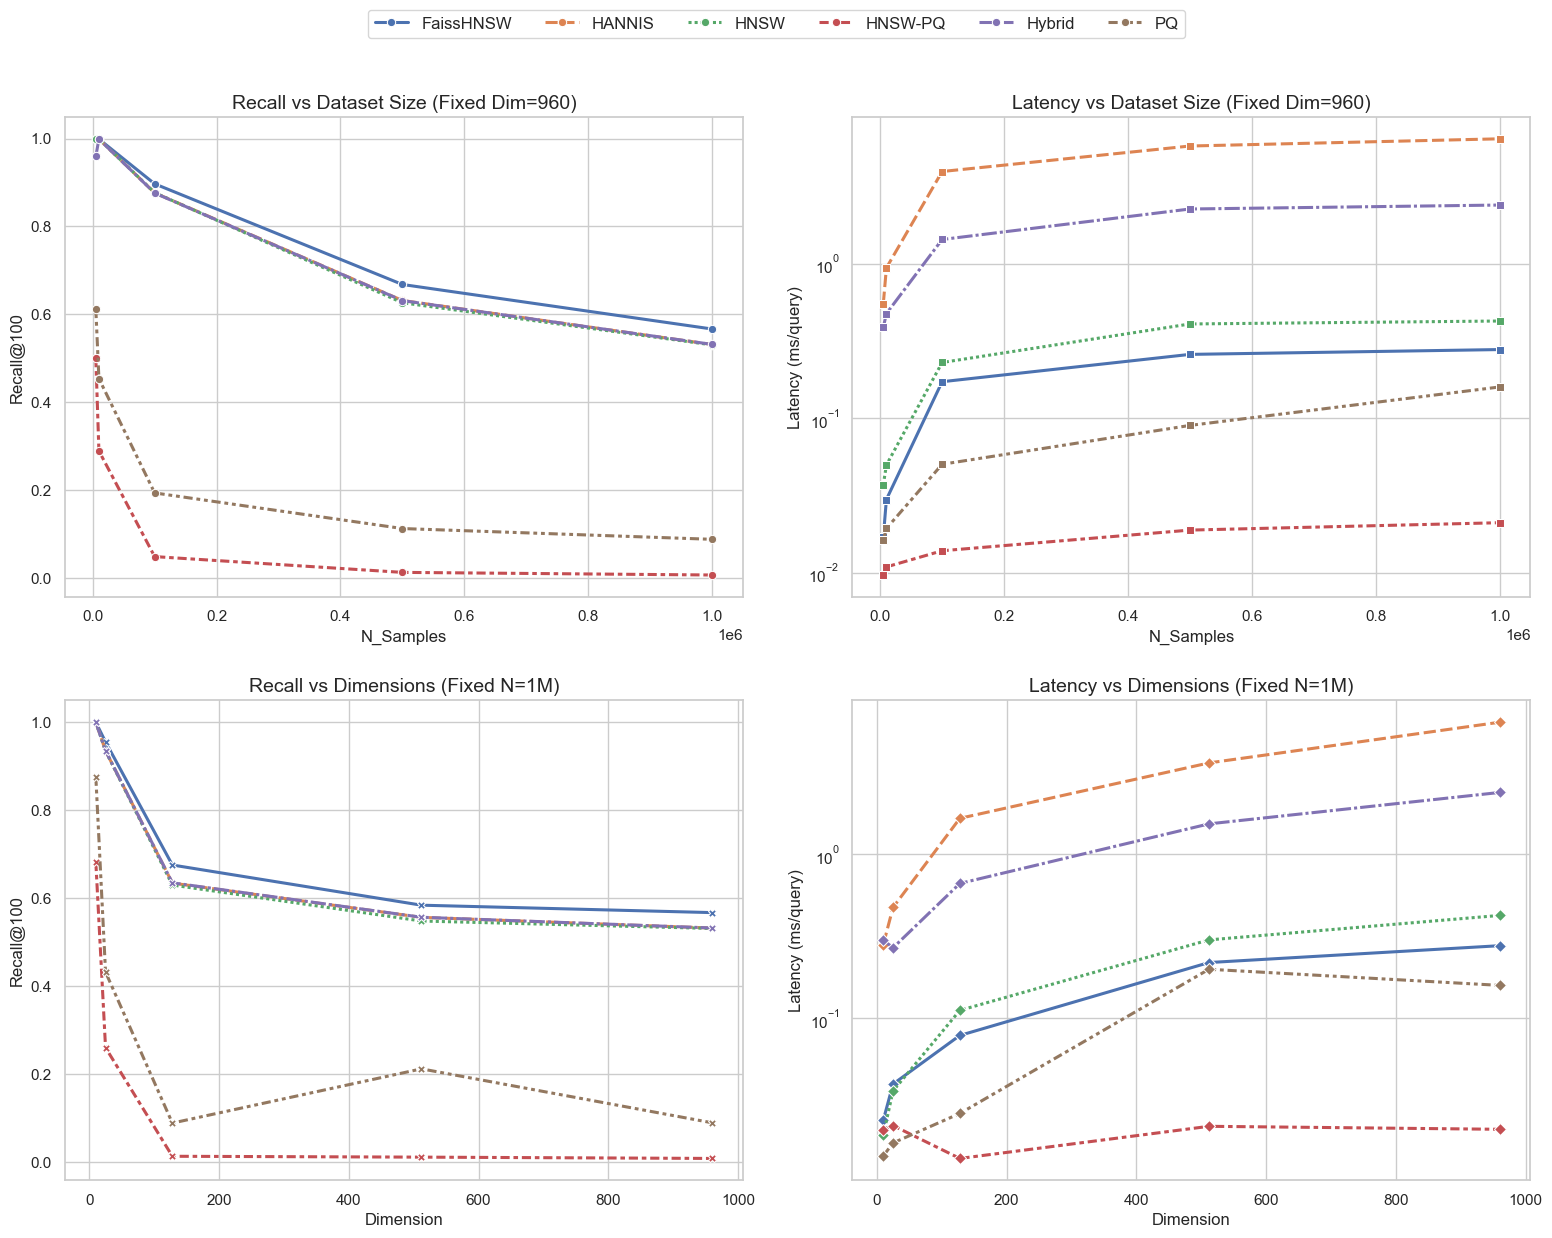

In [8]:
df = pd.read_csv(RESULT_PATH)

# กันกรณี latency ผิดปกติ
df = df[df["latency_mean_ms"] > 0].copy()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Vary N_Samples (ล็อค Dim=960)
df_n = df[df["Dimension"] == 960].copy()
df_n = df_n.sort_values(["Method", "N_Samples"])

# 1) Recall vs Dataset Size
sns.lineplot(data=df_n, x="N_Samples", y="recall@100", hue="Method", style="Method", marker="o", lw=2.2, ax=axes[0, 0])
axes[0, 0].set_title("Recall vs Dataset Size (Fixed Dim=960)", fontsize=14)
axes[0, 0].set_ylabel("Recall@100")

# 2) Latency vs Dataset Size
sns.lineplot(data=df_n, x="N_Samples", y="latency_mean_ms", hue="Method", style="Method", marker="s", lw=2.2, ax=axes[0, 1])
axes[0, 1].set_title("Latency vs Dataset Size (Fixed Dim=960)", fontsize=14)
axes[0, 1].set_ylabel("Latency (ms/query)")
axes[0, 1].set_yscale("log")

# Vary Dimension (ล็อค N=1M)
df_dim = df[df["N_Samples"] == 1000000].copy()
df_dim = df_dim.sort_values(["Method", "Dimension"])

# 3) Recall vs Dimensions
sns.lineplot(data=df_dim, x="Dimension", y="recall@100", hue="Method", style="Method", marker="X", lw=2.2, ax=axes[1, 0])
axes[1, 0].set_title("Recall vs Dimensions (Fixed N=1M)", fontsize=14)
axes[1, 0].set_ylabel("Recall@100")

# 4) Latency vs Dimensions
sns.lineplot(data=df_dim, x="Dimension", y="latency_mean_ms", hue="Method", style="Method", marker="D", lw=2.2, ax=axes[1, 1])
axes[1, 1].set_title("Latency vs Dimensions (Fixed N=1M)", fontsize=14)
axes[1, 1].set_ylabel("Latency (ms/query)")
axes[1, 1].set_yscale("log")

# จัดการตกแต่งความสวยงาม (Legend & Layout)
for ax in axes.ravel():
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=6, bbox_to_anchor=(0.5, 1.05), fontsize=12)

plt.tight_layout(pad=2.0)

fig_path = os.path.join(FIG_DIR, "smooth_trend_analysis_2D_Final.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved 2D trend graphs to: {fig_path}")
plt.show()